In [4]:
import os
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

In [5]:
def smooth_network(network, window=11, poly=3):
    """
    Smooth all S-parameters of a Network using Savitzky–Golay filter.
    Returns a new smoothed Network.
    """
    s = network.s.copy()
    n_freq, n_port, _ = s.shape

    s_smooth = np.zeros_like(s, dtype=complex)

    for i in range(n_port):
        for j in range(n_port):
            real_part = np.real(s[:, i, j])
            imag_part = np.imag(s[:, i, j])

            real_smooth = savgol_filter(real_part, window, poly)
            imag_smooth = savgol_filter(imag_part, window, poly)

            s_smooth[:, i, j] = real_smooth + 1j * imag_smooth

    smoothed_network = rf.Network(
        frequency=network.frequency,
        s=s_smooth,
        z0=network.z0
    )

    return smoothed_network


def load_directory(directory_path, window=30, poly=3):
    """
    Reads all .s2p files in a directory.
    Can Return two lists:
        {directory_name}_original
        {directory_name}_smoothed
    """

    directory_name = os.path.basename(os.path.normpath(directory_path))

    original_list = []
    smoothed_list = []

    for file in sorted(os.listdir(directory_path)):
        if file.lower().endswith(".s2p"):

            full_path = os.path.join(directory_path, file)

            # Load original network
            ntwk = rf.Network(full_path)

            # Use filename (without extension) as network name
            name = os.path.splitext(file)[0]
            ntwk.name = name

            original_list.append(ntwk)

            # Create smoothed version
            ntwk_smooth = smooth_network(ntwk, window, poly)
            ntwk_smooth.name = name

            smoothed_list.append(ntwk_smooth)

    # Dynamically create variable names
    globals()[f"{directory_name}_measured"] = original_list
    globals()[f"{directory_name}_smoothed"] = smoothed_list

    return original_list, smoothed_list


def avg_return_loss(ntwk):
    s11_db = ntwk.s_db[:,0,0]
    return np.mean(s11_db)
def worst_return_loss(ntwk):
    return np.max(ntwk.s_db[:640,0,0])   # closest to 0 dB
def avg_transmit_loss(ntwk):
    s11_db = ntwk.s_db[:,1,0]
    return np.mean(s11_db)
def worst_transmit_loss(ntwk):
    return np.max(ntwk.s_db[:,1,0])   # closest to 0 dB

In [6]:
from pathlib import Path
path1 = Path('GEECI_meas_18min_21_may_2026')

geeci_files = []
directory = path1
for file in directory.iterdir():
    geeci_files.append(file)
geeci_files

[WindowsPath('GEECI_meas_18min_21_may_2026/cal_data.s2p'),
 WindowsPath('GEECI_meas_18min_21_may_2026/cal_state.csa'),
 WindowsPath('GEECI_meas_18min_21_may_2026/DMD'),
 WindowsPath('GEECI_meas_18min_21_may_2026/SUB1'),
 WindowsPath('GEECI_meas_18min_21_may_2026/SUB2'),
 WindowsPath('GEECI_meas_18min_21_may_2026/SUB3')]

In [7]:
# refrencing files with the same names across different samples:
from pathlib import Path

# Define the parent directory
parent_dir = path1

# list to contain paths of all files found
thru_files_nos1 = []
thru_files_nos2 = []
thru_files_nos3 = []
thru_files_all = []
thru_covered_all = []

FCB_tr_overlap_30um = []
FCB_pillar_pitch_100um = []
FCB_tr_overlap_120um = []
# Search for files containing specific characters (e.g., "target")
# The '**' searches all subfolders recursively



matching_files = list(parent_dir.glob("**/*thru*.*"))
for file_path in matching_files:
    # print(f"Found file: {file_path.name} in {file_path.parent}")
    thru_files_all.append(file_path)

matching_files3 = list((Path('GEECI_meas_18min_21_may_2026') / 'DMD').glob("**/*tn*.*"))
for file_path in matching_files3:
    print(f"Found file: {file_path.name} in {file_path.parent}")
    thru_covered_all.append(file_path)

matching_files4 = list(parent_dir.glob("**/*15um*.*"))
for file_path in matching_files4:
    # print(f"Found file: {file_path.name} in {file_path.parent}")
    FCB_tr_overlap_30um.append(file_path)

matching_files5 = list(parent_dir.glob("**/*_60um*.*"))
for file_path in matching_files5:
    # print(f"Found file: {file_path.name} in {file_path.parent}")
    FCB_tr_overlap_120um.append(file_path)




Found file: tn1.s2p in GEECI_meas_18min_21_may_2026\DMD\SETA
Found file: tn2.s2p in GEECI_meas_18min_21_may_2026\DMD\SETA
Found file: tn3.s2p in GEECI_meas_18min_21_may_2026\DMD\SETA
Found file: TN1.s2p in GEECI_meas_18min_21_may_2026\DMD\SETB
Found file: TN2.s2p in GEECI_meas_18min_21_may_2026\DMD\SETB
Found file: TN3.s2p in GEECI_meas_18min_21_may_2026\DMD\SETB
Found file: tn4.s2p in GEECI_meas_18min_21_may_2026\DMD\SETB
Found file: tn5.s2p in GEECI_meas_18min_21_may_2026\DMD\SETB
Found file: tn6.s2p in GEECI_meas_18min_21_may_2026\DMD\SETB


In [8]:
thru_files_all

[WindowsPath('GEECI_meas_18min_21_may_2026/SUB3/SETA/thru1.s2p'),
 WindowsPath('GEECI_meas_18min_21_may_2026/SUB3/SETA/thru2.s2p'),
 WindowsPath('GEECI_meas_18min_21_may_2026/SUB3/SETA/thru3.s2p'),
 WindowsPath('GEECI_meas_18min_21_may_2026/SUB2/SetA/thru1.s2p'),
 WindowsPath('GEECI_meas_18min_21_may_2026/SUB2/SetA/thru2.s2p'),
 WindowsPath('GEECI_meas_18min_21_may_2026/SUB2/SetA/thru3.s2p'),
 WindowsPath('GEECI_meas_18min_21_may_2026/SUB1/SETA/thru1.s2p'),
 WindowsPath('GEECI_meas_18min_21_may_2026/SUB1/SETA/thru2.s2p'),
 WindowsPath('GEECI_meas_18min_21_may_2026/SUB1/SETA/thru3.s2p'),
 WindowsPath('GEECI_meas_18min_21_may_2026/DMD/SETB/thru1.s2p'),
 WindowsPath('GEECI_meas_18min_21_may_2026/DMD/SETB/thru2.s2p'),
 WindowsPath('GEECI_meas_18min_21_may_2026/DMD/SETB/thru3.s2p')]

(-70.0, 0.0)

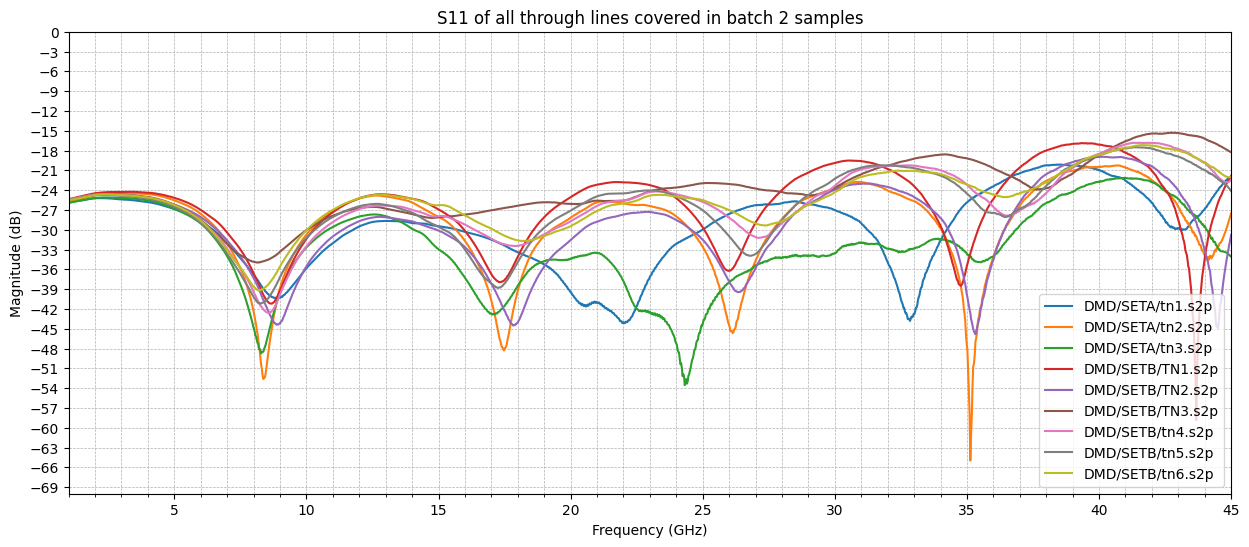

In [9]:
from matplotlib import ticker
from scipy.signal import find_peaks
dip1_freqs = []
dip2_freqs = []
dip3_freqs = []
dip4_freqs = []
# plotting the S11 of through lines nos1
plt.figure(figsize=(15,6))
plt.title("S11 of all through lines covered in batch 2 samples")

#changinf axis ticks
from matplotlib.ticker import MultipleLocator
ax = plt.gca()
# Set grid lines at every 3 dB on the y-axis
ax.yaxis.set_major_locator(MultipleLocator(3))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1e9))
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

for path in thru_covered_all:
    path_obj = Path(path)
    folder_label = "/".join(path_obj.parts[-3:])  # Get the last two directories

    ntwk = rf.Network(path)
    ntwk = smooth_network(ntwk, window=30, poly=3)
    s11 = ntwk.s_db[:,0,0]
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0, label=folder_label)
plt.ylim(-70, 0)



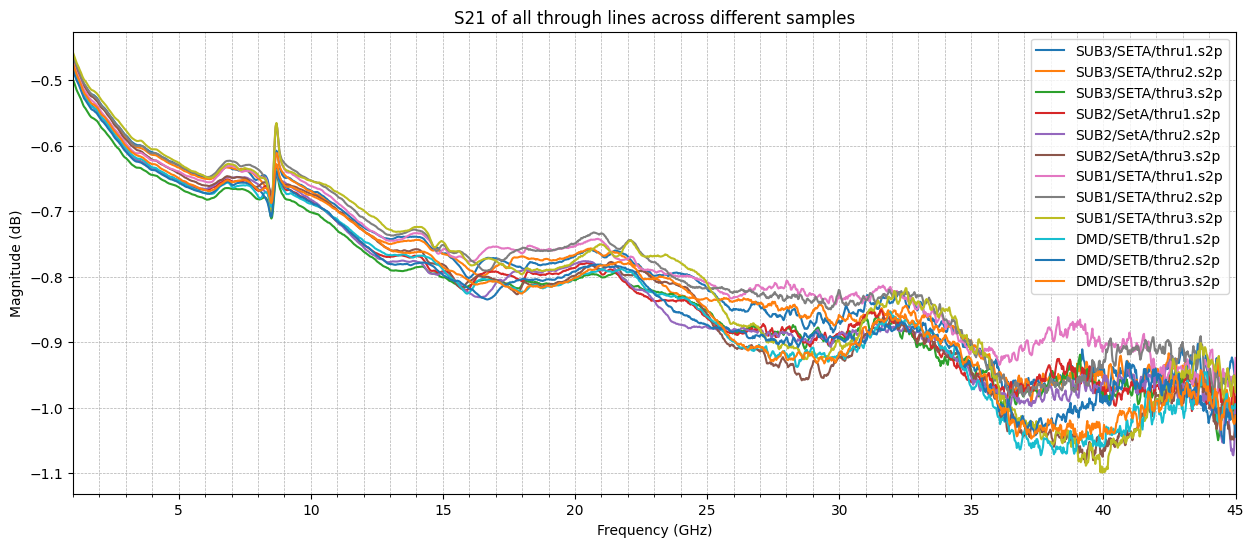

In [10]:
from matplotlib import ticker
from scipy.signal import find_peaks
dip1_freqs = []
dip2_freqs = []
dip3_freqs = []
dip4_freqs = []
# plotting the S11 of through lines nos1
plt.figure(figsize=(15,6))
plt.title("S21 of all through lines across different samples")

#changinf axis ticks
from matplotlib.ticker import MultipleLocator
ax = plt.gca()
# Set grid lines at every 3 dB on the y-axis
# ax.yaxis.set_major_locator(MultipleLocator(3))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1e9))
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

for path in thru_files_all:
    path_obj = Path(path)
    folder_label = "/".join(path_obj.parts[-3:])  # Get the last two directories

    ntwk = rf.Network(path)
    sm_ntwk = smooth_network(ntwk, window=11, poly=3)
    sm_ntwk.frequency.unit = 'GHz'
    sm_ntwk.plot_s_db(m=1,n=0, label=folder_label)



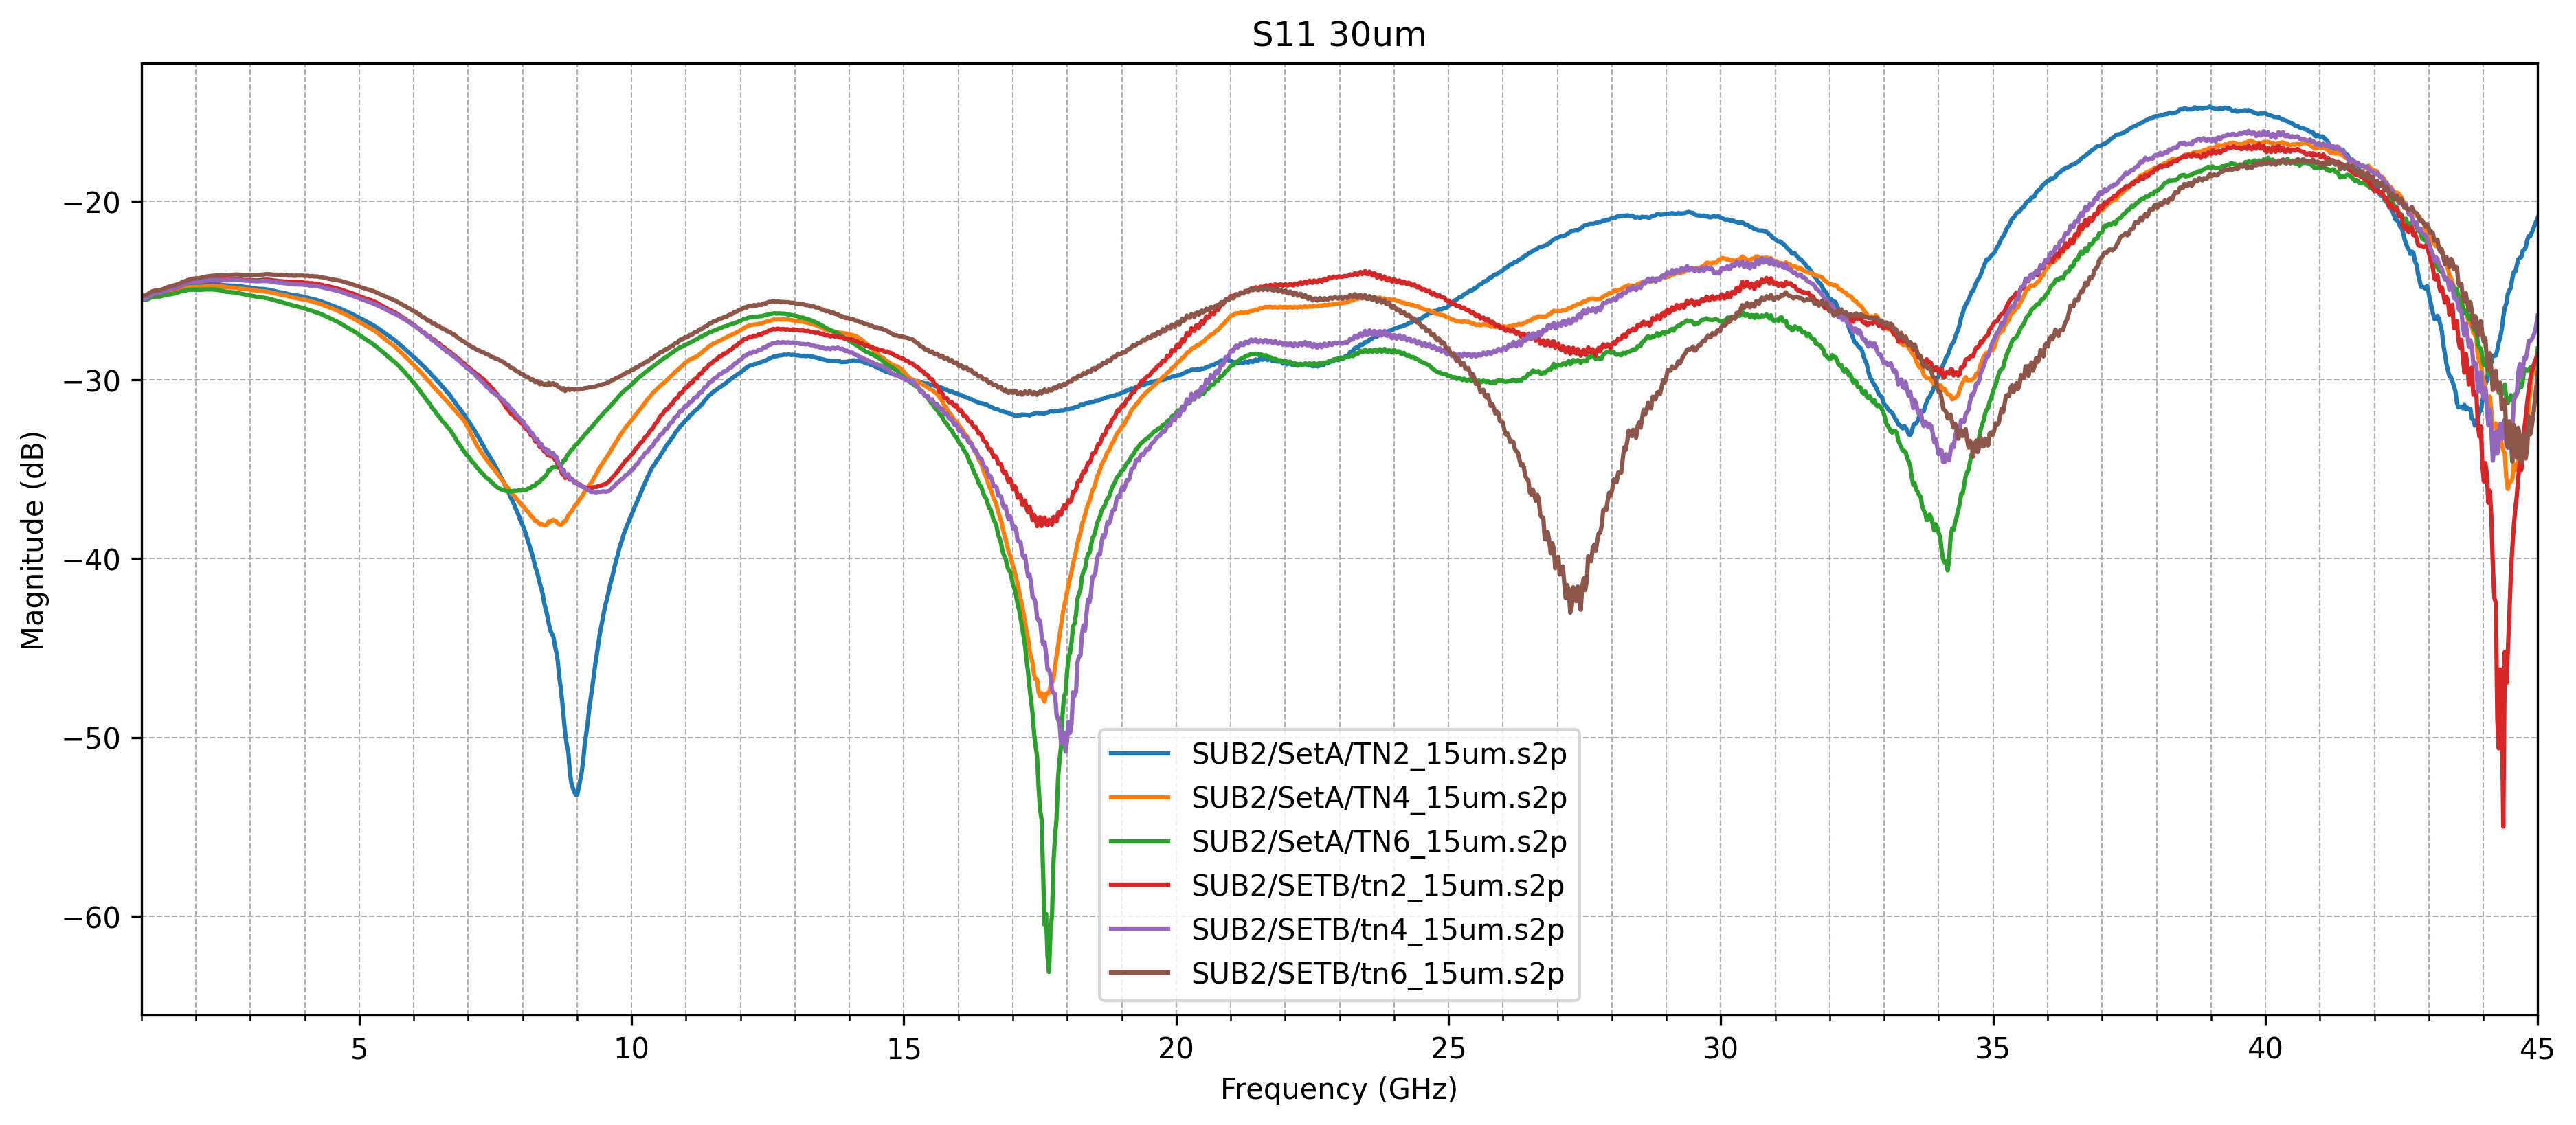

In [11]:
from matplotlib import ticker
from scipy.signal import find_peaks

# plotting the S11 of through lines nos1
plt.figure(figsize=(15,6), dpi=300)
plt.title("S11 30um")

#changinf axis ticks
from matplotlib.ticker import MultipleLocator
ax = plt.gca()
# Set grid lines at every 3 dB on the y-axis
# ax.yaxis.set_major_locator(MultipleLocator(3))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1e9))
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

for path in FCB_tr_overlap_30um:
    path_obj = Path(path)
    folder_label = "/".join(path_obj.parts[-3:])  # Get the last two directories

    ntwk = rf.Network(path)
    ntwk = smooth_network(ntwk, window=11, poly=3)
    s11 = ntwk.s_db[:,0,0]
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0, label=folder_label)
# plt.ylim(-60, 0)



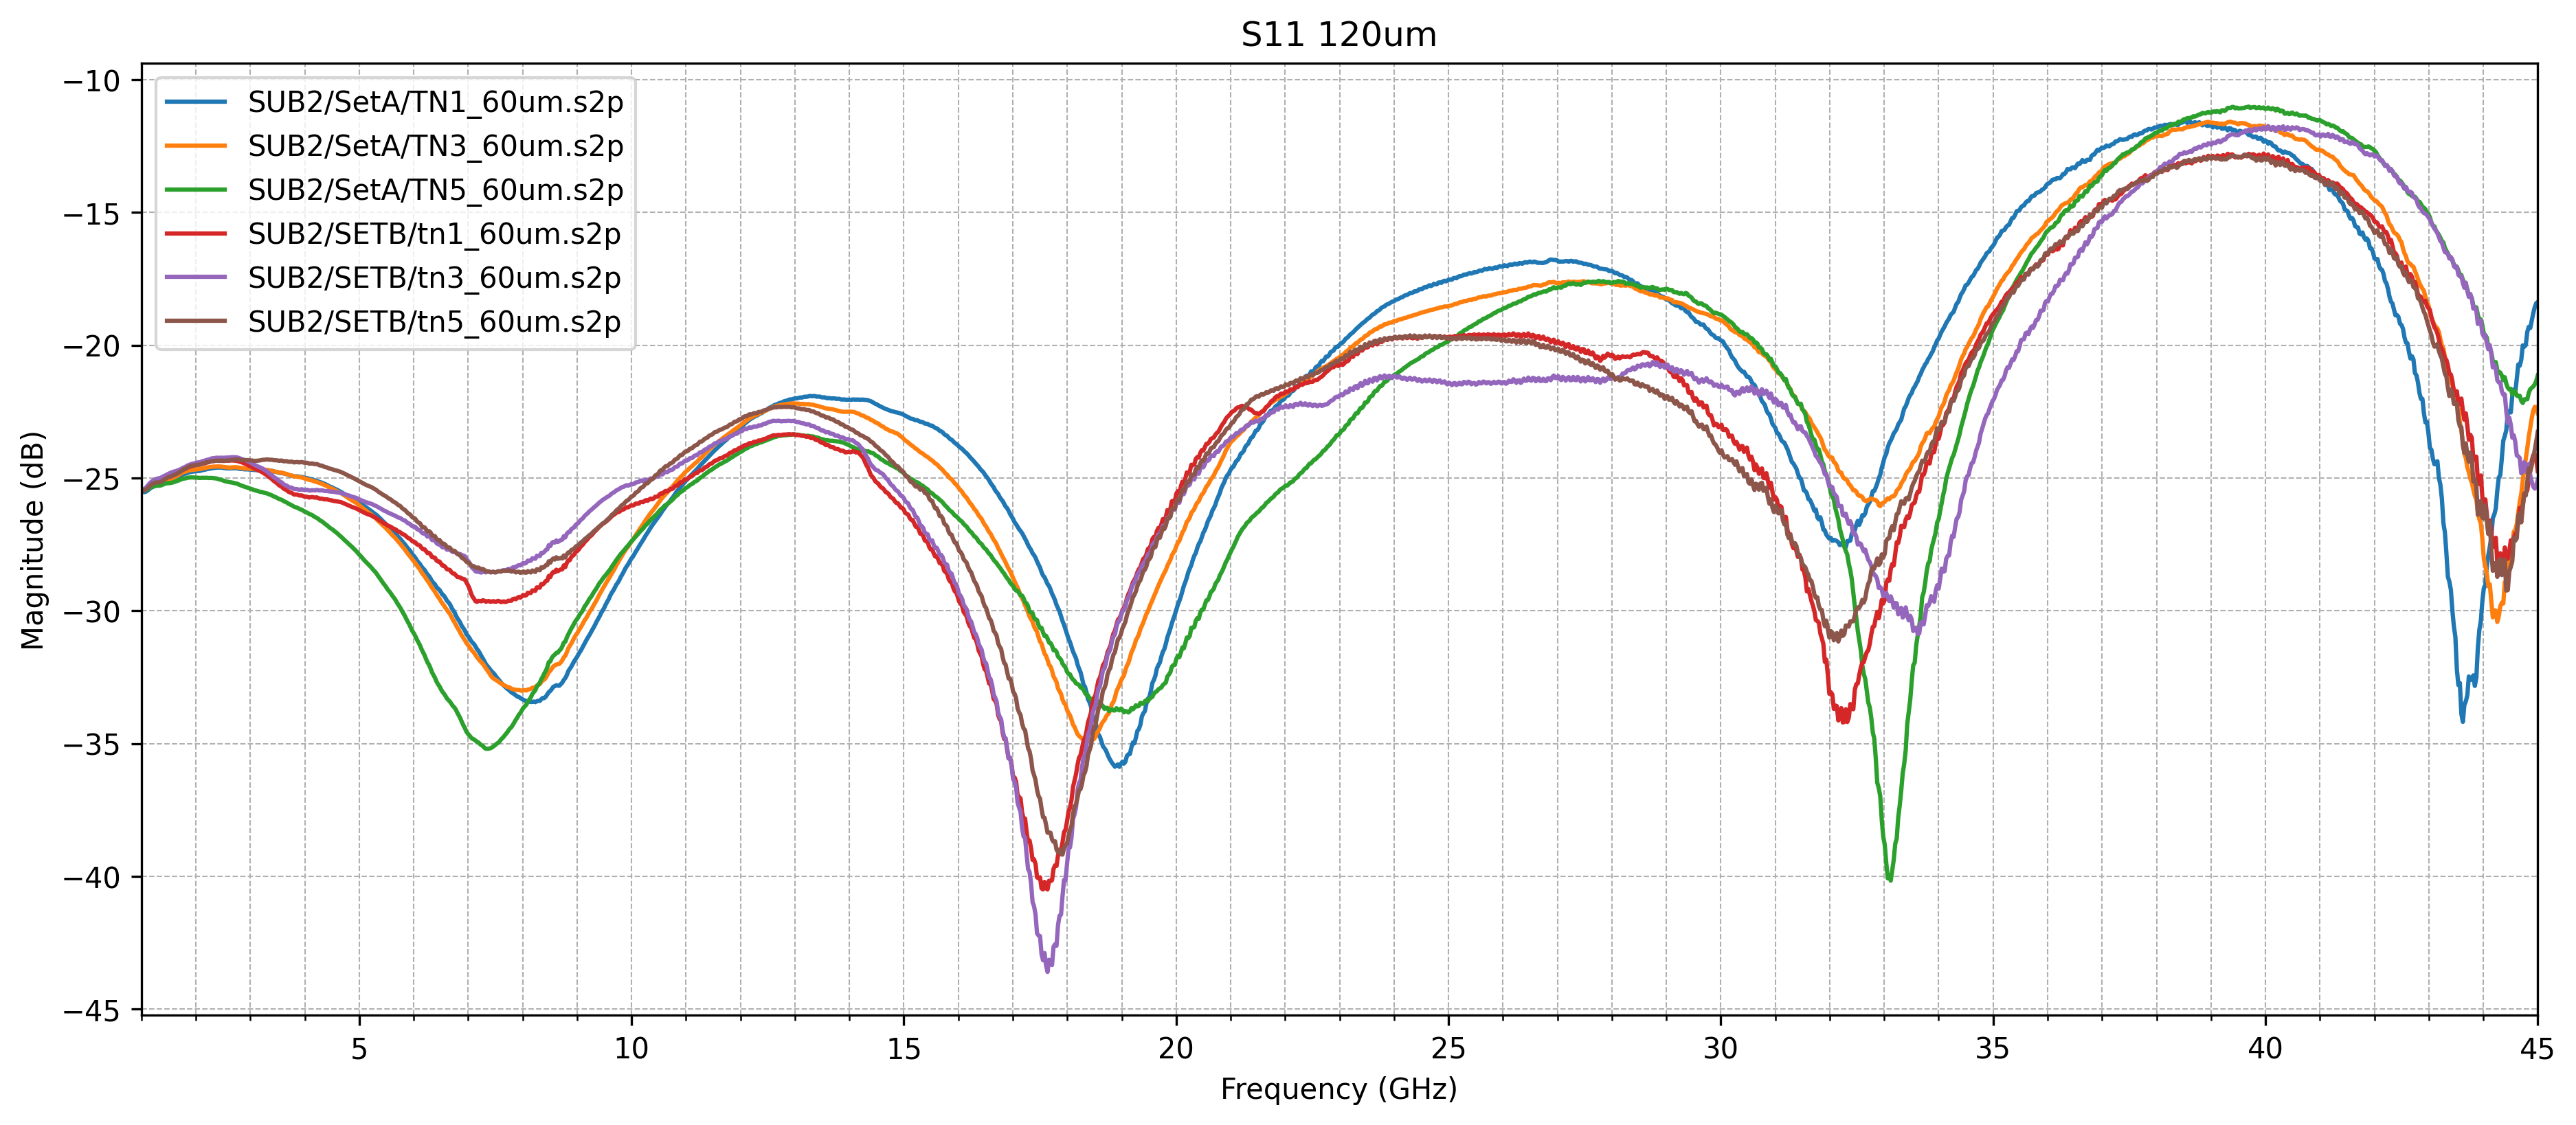

In [12]:
from matplotlib import ticker
from scipy.signal import find_peaks

# plotting the S11 of through lines nos1
plt.figure(figsize=(15,6), dpi=300)
plt.title("S11 120um")

#changinf axis ticks
from matplotlib.ticker import MultipleLocator
ax = plt.gca()
# Set grid lines at every 3 dB on the y-axis
# ax.yaxis.set_major_locator(MultipleLocator(3))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1e9))
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

for path in FCB_tr_overlap_120um:
    path_obj = Path(path)
    folder_label = "/".join(path_obj.parts[-3:])  # Get the last two directories

    ntwk = rf.Network(path)
    ntwk = smooth_network(ntwk, window=11, poly=3)
    s11 = ntwk.s_db[:,0,0]
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0, label=folder_label)
# plt.ylim(-60, 0)

# ABCD matrix

In [13]:
#1. Load the .s2p file 
ntw = rf.Network('GEECI_meas_18min_21_may_2026/SUB3/SETA/thru1.s2p')
length_A3_thru_1 = (6500 - (128.8+139.4)) * 1e-6  # Convert micrometers to meters
# 2. Extract the ABCD matrix for every frequency point
# This returns a NumPy array of shape (N, 2, 2) where N is the number of frequency points
abcd_matrices = ntw.a 

# Example: Get the ABCD matrix at the first frequency point
freq_index = 150
freq_hz = ntw.f[freq_index]
abcd_matrix = abcd_matrices[freq_index]

print(f"Frequency: {freq_hz / 1e9:.2f} GHz")
print("ABCD Matrix:")
print(abcd_matrix)

Frequency: 5.12 GHz
ABCD Matrix:
[[-5.37781640e-02+6.87657065e-02j  2.61646943e+00+5.59504765e+01j]
 [-9.71491970e-04+1.78458575e-02j -6.01912799e-02+6.87234796e-02j]]


In [14]:
abcd_matrix[0,1]

np.complex128(2.6164694290748756+55.95047650226655j)

In [15]:
import cmath
# Calculate inverse hyperbolic values
A = abcd_matrix[0,0]
gamma_l = cmath.acosh(A)
print("Inverse Hyperbolic Cosine:", gamma_l)

gamma = gamma_l/length_A3_thru_1
A


Inverse Hyperbolic Cosine: (0.06881057501828178+1.6244731964524677j)


np.complex128(-0.05377816396970267+0.06876570652512806j)

In [16]:
lambda_m = (2 * np.pi) / gamma.imag
print("Lambda:", lambda_m)

Lambda: 0.024103539709236097


In [17]:
B = abcd_matrix[0,1]
B/(cmath.sinh(gamma_l))

np.complex128(55.88837548110708-2.8203509036694046j)

Text(0.5, 0, 'Frequency (GHz)')

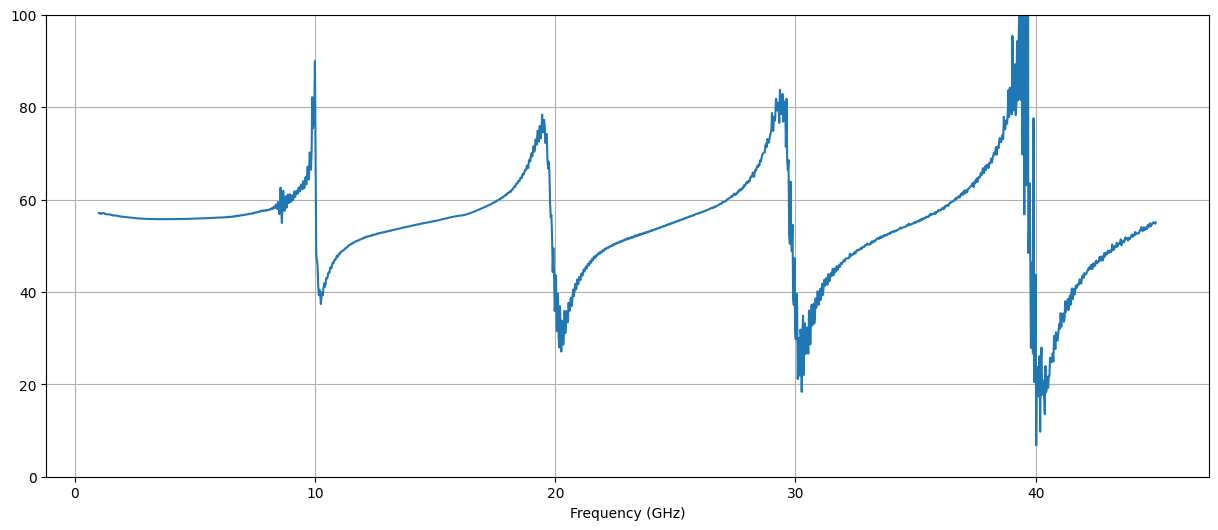

In [18]:
plt.figure(figsize=(15,6))
Zo = []
for i in range(len(ntw.f)):
    A = abcd_matrices[i,0,0]
    gamma_l = cmath.acosh(A)
    B = abcd_matrices[i,0,1]
    Zo.append(B/(cmath.sinh(gamma_l)))
plt.ylim(0,100)
plt.plot(ntw.f/1e9, np.real(Zo))
plt.grid(True)
plt.xlabel("Frequency (GHz)")   

In [19]:
# we will write a function to extract beta and zo from amcd matrix
def extract_gamma_zo(abcd_matrix, length):
    A = abcd_matrix[0,0]
    gamma_l = cmath.acosh(A)
    gamma = gamma_l / length
    Zo = cmath.sqrt(abcd_matrix[0,1]/abcd_matrix[1,0])
    return gamma, Zo

# now we will use our function to form the ABCD matrx of desired length
def form_abcd_for_length(abcd_matrix, desired_length, original_length):
    gamma, Zo = extract_gamma_zo(abcd_matrix, original_length)
    A = np.cosh(gamma * desired_length)
    B = Zo * np.sinh(gamma * desired_length)
    C = (1/Zo) * np.sinh(gamma * desired_length)
    D = np.cosh(gamma * desired_length)
    abcd_fr_len = np.array([[A, B], [C, D]])
    inv_abcd_fr_len = np.array([[A, -B], [-C, D]])
    return abcd_fr_len, inv_abcd_fr_len


In [30]:
#1. Load the .s2p file 
thru_ntw = rf.Network('GEECI_meas_18min_21_may_2026/SUB2/SETA/thru1.s2p')
length_2A_thru_1 = (6500 - (109.8 +124.4)) * 1e-6  # Convert micrometers to meters
freq_index = 37 # 2.02 GHz
freq_hz = thru_ntw.f[freq_index]
thru_abcd_matrix = thru_ntw.a[freq_index]
# freq_hz

# we will extract abcd matrix for len of 375um to de embed the thru line from the covered line. but we need to compensate for the dicing 
# we will add 115um 
thru_t_490um, inv_thru_t_490um = form_abcd_for_length(thru_abcd_matrix, 490e-6, length_2A_thru_1)


In [21]:
covered_thru_ntw = rf.Network('GEECI_meas_18min_21_may_2026/DMD/SETA/tn2.s2p')
abcd_covered_thru = covered_thru_ntw.a[freq_index]
covered_abcd_5270um = inv_thru_t_490um @ abcd_covered_thru @ inv_thru_t_490um

### Total matrix is $[T_{thru}][T_{covered}][T_{lumped}][T_{covered}][T_{lumped}][T_{covered}][T_{thru}]$

In [31]:
# now we have 5500um long covered through line parameters, uncovered through line parameters, now we can de embed the transition. 
fcb_30um_ntw = rf.Network('GEECI_meas_18min_21_may_2026/SUB2/SETA/tn6_15um.s2p')
abcd_fcb_30 = fcb_30um_ntw.a[freq_index]

#thru is around 490 to 500um because dicing cuts the die by around 110-115um on each side. so the through will increase by the same and the covered will decrease by the same. 
#deembedding uncovered through lines
fcb30_de_thru = inv_thru_t_490um @ abcd_fcb_30 @ inv_thru_t_490um
#deembedding covered through lines
covered_abcd_385um, inv_covered_abcd_385um = form_abcd_for_length(covered_abcd_5270um, 385e-6, 5270e-6)

fcb30_de_covered = inv_covered_abcd_385um @ fcb30_de_thru @ inv_covered_abcd_385um
fcb30_de_covered


array([[ 8.59322012e-01+2.51246669e-02j,  4.38361682e+00+2.53486271e+01j],
       [-9.60842000e-05+1.02955021e-02j,  8.59924503e-01+2.42406920e-02j]])

### Now we have $[T_{inner}]  =  [T_{lumped}][T_{covered}][T_{lumped}]$

#### Using a gemini code to solve the problem numerically.

In [28]:
import numpy as np
from scipy.optimize import least_squares

# ==========================================
# 1. Mock Data (Replace with your actual data)
# ==========================================
# Example 2x2 complex matrices for demonstration
T_covered,_ = form_abcd_for_length(covered_abcd_5270um, 4440e-6, 5270e-6)
T_inner = fcb30_de_covered

# ==========================================
# 2. Matrix Construction
# ==========================================
def build_T_lumped(L, C, w):
    """
    Constructs the T_lumped matrix given parameters L, C, and w.
    REPLACE the expressions below with your actual matrix structure.
    """
    T = np.zeros((2, 2), dtype=complex)
    
    # Example expressions:
    T[0, 0] = 1 - w*w*L*C
    T[0, 1] = 1j*w*L 
    T[1, 0] = 1j*w*(2*C - w*w*L*C*C)
    T[1, 1] = 1 - w*w*L*C
    
    return T

# ==========================================
# 3. The Objective Function
# ==========================================
def objective_function(params, T_covered, T_inner):
    """
    Calculates the difference between the calculated T_final and the actual T_final.
    """
    # Unpack the current guess for your variables
    L, C = params 
    
    # Build T_lumped with the current guesses
    T_lumped = build_T_lumped(L, C, 2.2e9)
    
    # Calculate the resulting matrix using the '@' operator for matrix multiplication
    T_calc = T_lumped @ T_covered @ T_lumped
    
    # Calculate the error (residual) matrix
    error_matrix = T_calc - T_inner
    
    # Flatten the matrix into a 1D array
    error_flat = error_matrix.flatten()
    
    # CRITICAL STEP: Scipy needs a real-valued 1D array to minimize.
    # We concatenate the real parts and imaginary parts into one long array.
    # If the solver drives both real and imag parts to 0, the complex error is 0.
    return np.concatenate([np.real(error_flat), np.imag(error_flat)])

# ==========================================
# 4. Solve the System
# ==========================================
# Provide an initial guess for x and y. 
# (Good initial guesses are very important for non-linear problems!)
initial_guess = [49e-12, 7e-15]

# Run the least squares optimization
result = least_squares(
    objective_function, 
    x0=initial_guess, 
    args=(T_covered, T_inner),
    method='lm' # Levenberg-Marquardt is usually great for this type of problem
)

# ==========================================
# 5. Review Results
# ==========================================
if result.success:
    best_x, best_y = result.x
    print(f"Optimization Successful!")
    print(f"Solved x: {best_x:.6e}")
    print(f"Solved y: {best_y:.6e}")
    
    # Optional: Verify the solution
    T_lumped_solved = build_T_lumped(best_x, best_y, 2.2e9)
    T_check = T_lumped_solved @ T_covered @ T_lumped_solved
    print("\nVerification (T_calc - T_inner):")
    print(np.round(T_check - T_inner, 6))
else:
    print("Optimization failed to converge.")
    print(result.message)

Optimization Successful!
Solved x: 2.335537e-10
Solved y: 6.959079e-15

Verification (T_calc - T_inner):
[[-6.30200e-03-0.001213j -3.05781e-01-0.009182j]
 [-2.40000e-05+0.000456j -6.90400e-03-0.000329j]]


### Setting up ADS simulation using the lumped values. The code below is for RLGC extraction

In [35]:


def extract_rlgc(abcd_matrix, length, frequency):
    """
    Extracts per-unit-length RLGC parameters from an ABCD matrix.
    
    Parameters:
    abcd_matrix (np.ndarray): 2x2 complex ABCD matrix.
    length (float): Physical length of the transmission line in meters.
    frequency (float): Evaluation frequency in Hertz.
    
    Returns:
    tuple: (R, L, G, C) per unit length
           R in Ohms/m, L in Henries/m, G in Siemens/m, C in Farads/m.
    """
    # Angular frequency
    omega = 2 * np.pi * frequency
    
    # Extract ABCD elements
    A = abcd_matrix[0, 0]
    B = abcd_matrix[0, 1]
    C = abcd_matrix[1, 0]
    # D = abcd_matrix[1, 1] # Not strictly needed for a symmetric line
    
    # 1. Calculate Characteristic Impedance (Z0)
    # Z0 = sqrt(B / C)
    Z0 = np.sqrt(B / C)
    
    # 2. Calculate Complex Propagation Constant (gamma)
    # gamma = (1 / length) * arccosh(A)
    # Since phase wrapping is not an issue at this length/frequency,
    # the principal branch computed by np.arccosh is sufficient.
    gamma = (1 / length) * np.arccosh(A)
    
    # 3. Calculate Series Impedance (Z) and Shunt Admittance (Y) per unit length
    Z = gamma * Z0
    Y = gamma / Z0
    
    # 4. Extract RLGC
    R = np.real(Z)
    L = np.imag(Z) / omega
    G = np.real(Y)
    C = np.imag(Y) / omega
    
    return R, L, G, C


In [38]:
R_ext, L_ext, G_ext, C_ext = extract_rlgc(thru_t_490um, 490e-6, 2.02e9)
print(f"R: {R_ext:.4f} Ohms/m ")
print(f"L: {L_ext:.4e} H/m ")
print(f"G: {G_ext:.4f} S/m ")
print(f"C: {C_ext:.4e} F/m ")

R: 1035.2161 Ohms/m 
L: 4.6130e-07 H/m 
G: 0.0023 S/m 
C: 1.4397e-10 F/m 


In [39]:
R_ext, L_ext, G_ext, C_ext = extract_rlgc(covered_abcd_385um, 385e-6, 2.02e9)
print(f"R: {R_ext:.4f} Ohms/m ")
print(f"L: {L_ext:.4e} H/m ")
print(f"G: {G_ext:.4f} S/m ")
print(f"C: {C_ext:.4e} F/m ")

R: 1019.0071 Ohms/m 
L: 4.5493e-07 H/m 
G: -0.0066 S/m 
C: 1.9930e-10 F/m 
